In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper



In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
wikipwdia_api_wrapper=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=wikipwdia_api_wrapper)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("what is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation me'

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_aPI_KEY"]= os.getenv("GROQ_API_KEY")



In [7]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\aishl\AppData\Local\Temp\ipykernel_19312\735679136.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [8]:
tavily.invoke("Provice me the recent AI news")

[{'title': 'March 2026 AI News Roundup: Breakthroughs and the Fights, Forecasts, and Fears - Peterson Technology Partners',
  'url': 'https://www.ptechpartners.com/2026/04/07/march-2026-ai-news-roundup-breakthroughs-and-the-fights-forecasts-and-fears/',
  'content': '“There’s a lot of companies that are doing layoffs right now andblaming it on AI. But they’re actually doing layoffs because the businesses aren’t performing particularly well. And it’s a convenient excuse.” \n\nCount OpenAI among companies that are hiring, with The Information reporting the leading AI firm is looking to nearly double its headcount(4,500 to 8,000) by the end of 2026. \n\nOthers, like Circle Co-Founder and CEO Jeremy Allaire, see AI agents soon replacing a “huge percentage of work that’s currently performed by humans on a massive scale” (Yahoo Finance interview from March).  \n\nBlackRock CEO Larry Fink noted in his annual letter to shareholders that AI is leading to “K-shaped” results for companies, too, w

In [9]:
## combine all the tools

tools=[arxiv,wiki,tavily]

In [10]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.1-8b-instant")
llm_with_tools=llm.bind_tools(tools)


In [11]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

llm_with_tools.invoke([HumanMessage(content=f"what is recent AI News")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jfdcwd5y2', 'function': {'arguments': '{"query":"recent AI News"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 552, 'total_tokens': 572, 'completion_time': 0.023369749, 'completion_tokens_details': None, 'prompt_time': 0.05624396, 'prompt_tokens_details': None, 'queue_time': 0.054784623, 'total_time': 0.079613709}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df141-2a0f-7f01-943c-a4bbadaeab6b-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI News'}, 'id': 'jfdcwd5y2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 552, 'output_tokens': 20, 'total_tokens': 572})

In [12]:
llm_with_tools.invoke([HumanMessage(content=f"what is recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Recent AI News'},
  'id': 'r720rkhzv',
  'type': 'tool_call'}]

In [13]:
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

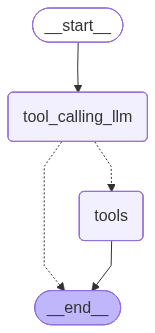

In [14]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


# build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))




In [16]:
messages = graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m  in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (5w7xdx5j0)
 Call ID: 5w7xdx5j0
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base
